# Data and Environment Set-Up

In [ ]:
!pip install torch numpy matplotlib seaborn scikit-learn

Important packages used

In [ ]:
# basic
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
from pathlib import Path
from collections import defaultdict, Counter
import pandas as pd

# pytorch packages
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset, random_split
from torchvision.models import resnet18, ResNet18_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau, OneCycleLR

# sklearn packages
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, f1_score

# setting device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

Reading in sequential training data from Drive

In [ ]:
# REPLACE WITH REAL FILE PATHS IF NOT WORKING IN COLAB
data = np.load('/content/drive/MyDrive/NFL_Route_Tracker/training_data/training_data.npz')
X_train = data['X_train']
y_train = data['y_train']

# loaading data
with open('/content/drive/MyDrive/NFL_Route_Tracker/training_data/class_mapping.json', 'r') as f:
    class_info = json.load(f)

class_names = class_info['class_names']
num_classes = class_info['num_classes']

print(f"X shape: {X_train.shape}")
print(f"y shape: {y_train.shape}")
print(f"Classes: {class_names}")
print(f"Distribution: {np.bincount(y_train)}")

X shape: (9966, 64, 2)
y shape: (9966,)
Classes: ['comeback', 'corner', 'curl', 'dig', 'drag', 'flat', 'out', 'post', 'slant', 'streak', 'wheel']
Distribution: [ 438  618 1288 1050  626 1076 1062  870 1030 1278  630]


Setting up sequential data for tensor formatting

In [ ]:
# converting data into pytorch format
num_samples = len(X_train)

# setting up train/val/test sets
indices = np.random.permutation(num_samples)
train_end = int(num_samples * 0.8)
val_end = int(num_samples * 0.9)
train_idx = indices[:train_end]
val_idx = indices[train_end:val_end]
test_idx = indices[val_end:]

# convert to tensors (batch, channels, length)
X_tensor = torch.FloatTensor(X_train).permute(0, 2, 1)
y_tensor = torch.LongTensor(y_train)

train_dataset = TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
val_dataset = TensorDataset(X_tensor[val_idx], y_tensor[val_idx])
test_dataset = TensorDataset(X_tensor[test_idx], y_tensor[test_idx])

# setting up dataloader classes
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 7972, Val: 997, Test: 997


Reading in image training data from Drive

In [ ]:
# same process as above, but loading in image data for 2D CNN
data_img = np.load('/content/drive/MyDrive/NFL_Route_Tracker/training_data/image_training_data.npz')
X_train_img = data_img['X_train']
y_train_img = data_img['y_train']

with open('/content/drive/MyDrive/NFL_Route_Tracker/training_data/class_mapping.json') as f:
    class_info = json.load(f)
class_names = class_info['class_names']
num_classes  = class_info['num_classes']

print(f"X shape : {X_train_img.shape}")
print(f"y shape : {y_train_img.shape}")

X shape : (10249, 3, 64, 64)
y shape : (10249,)


Setting up image data for tensor formatting.

In [ ]:
# normalize to ImageNet stats for using pretrained ResNet models
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# same process as above, splitting indices for train/val/test split
num_samples_img = len(X_train_img)
indices_img = np.random.permutation(num_samples_img)
train_end_img = int(num_samples_img * 0.8)
val_end_img = int(num_samples_img * 0.9)
train_idx_img = indices_img[:train_end_img]
val_idx_img = indices_img[train_end_img:val_end_img]
test_idx_img = indices_img[val_end_img:]

# convert to float tensors in [0, 1]
X_float = torch.FloatTensor(X_train_img.astype(np.float32) / 255.0)  # (N, 3, 64, 64)
y_tensor = torch.LongTensor(y_train_img)

# Training augmentation - needed LLM help
# applied per-batch inside the loader via a wrapper dataset to augment images
class AugmentedDataset(torch.utils.data.Dataset):
    """Wraps a TensorDataset and applies augmentation transforms on-the-fly."""
    def __init__(self, X, y, augment = True):
        self.X = X
        self.y = y
        if augment:
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(p = 0.5),
                transforms.RandomRotation(degrees = 8),
                transforms.ColorJitter(brightness = 0.15, contrast = 0.15),
                transforms.Normalize(mean = IMAGENET_MEAN, std=IMAGENET_STD),
            ])
        else:
            self.transform = transforms.Normalize(mean = IMAGENET_MEAN, std = IMAGENET_STD)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.transform(self.X[idx]), self.y[idx]

# only augmenting training data
train_dataset_img = AugmentedDataset(X_float[train_idx_img], y_tensor[train_idx_img], augment = True)
val_dataset_img = AugmentedDataset(X_float[val_idx_img], y_tensor[val_idx_img], augment = False)
test_dataset_img = AugmentedDataset(X_float[test_idx_img], y_tensor[test_idx_img], augment = False)

# finalized train/val/test sets
train_loader_img = DataLoader(train_dataset_img, batch_size = 64, shuffle = True, num_workers = 2)
val_loader_img = DataLoader(val_dataset_img, batch_size = 64, shuffle = False, num_workers = 2)
test_loader_img = DataLoader(test_dataset_img, batch_size = 64, shuffle = False, num_workers = 2)

print(f"Train: {len(train_dataset_img)} | Val: {len(val_dataset_img)} | Test: {len(test_dataset_img)}")

Train: 8199 | Val: 1025 | Test: 1025


---

# Model Definitions

Defining simple CNN for baseline modeling

In [ ]:
class RouteCNN(nn.Module):
  def __init__(self, num_classes = 11):
    super().__init__()
    # input layer, x and y positions
    self.conv1 = nn.Conv1d(2, 64, kernel_size = 5, padding = 2)
    self.bn1 = nn.BatchNorm1d(64)
    self.conv2 = nn.Conv1d(64, 128, kernel_size = 5, padding = 2)
    self.bn2 = nn.BatchNorm1d(128)
    self.conv3 = nn.Conv1d(128, 256, kernel_size = 3, padding = 1)
    self.bn3 = nn.BatchNorm1d(256)
    self.pool = nn.AdaptiveAvgPool1d(1)
    self.dropout = nn.Dropout(.2)
    # output layer, 11 classes
    self.fc = nn.Linear(256, num_classes)

  def forward(self, x):
    # ReLu activation functions
    x = F.relu(self.bn1(self.conv1(x)))
    x = F.relu(self.bn2(self.conv2(x)))
    x = F.relu(self.bn3(self.conv3(x)))
    # pooling and dropout applications
    x = self.pool(x).squeeze(-1)
    x = self.dropout(x)
    return self.fc(x)

Defining Transformer-based model

In [ ]:
# required to inject positional encoding into trajectory data
# cannibalized from https://machinelearningmastery.com/positional-encodings-in-transformer-models/
class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len = 64, dropout = 0.1):
    super().__init__()
    self.dropout = nn.Dropout(p=dropout)

    # creat matrix of shape (max length, dimensions)
    pe = torch.zeros(max_len, d_model)
    # vector shape (max length)
    position = torch.arange(0, max_len).unsqueeze(1).float()
    # vector shape (dimensions)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
    # apply sine to even indices
    pe[:, 0::2] = torch.sin(position * div_term)
    # apply cosine to odd indices
    pe[:, 1::2] = torch.cos(position * div_term)
    # register the positional encoding as a buffer
    self.register_buffer('pe', pe.unsqueeze(0))

  def forward(self, x):
    x = x + self.pe[:, :x.size(1)]
    return self.dropout(x)

# main transormer encoder class
class RouteTransformer(nn.Module):
    def __init__(self, num_classes = 11, d_model = 128, nhead = 8, num_layers = 4):
        super().__init__()
        # input layer  for two positions
        self.proj = nn.Linear(2, d_model)
        # encoding data
        self.pos = PositionalEncoding(d_model)
        # encoder layer with dropout
        encoder_layer = nn.TransformerEncoderLayer(d_model = d_model, nhead = nhead, dim_feedforward = 512,
                                                   dropout = 0.1, batch_first = True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers)
        self.classifier = nn.Linear(d_model, num_classes)

    def forward(self, x):
        # x: (batch, 2, 64), transpose to (batch, 64, 2)
        x = x.transpose(1, 2)
        x = self.proj(x)
        x = self.pos(x)
        x = self.transformer(x)
        # global average
        x = x.mean(dim = 1)
        return self.classifier(x)

Defining LSTM Model

In [ ]:
class RouteLSTM(nn.Module):
  def __init__(self, num_classes=11, hidden_dim = 128):
    super().__init__()
    # bidirectional layers with 128 dim each
    self.lstm = nn.LSTM(input_size = 2, hidden_size = hidden_dim,
                        num_layers = 2, batch_first=True,
                        bidirectional = True)
    # passing in 128 * 2 to final MLP with dropout
    self.classifier = nn.Sequential(nn.Linear(hidden_dim * 2, 128),
                                    nn.ReLU(),
                                    nn.Dropout(0.2),
                                    nn.Linear(128, num_classes))

  def forward(self, x):
    # x: (batch, 2, 64), transpose to (batch, 64, 2)
    x = x.transpose(1, 2)
    _, (h_n, _) = self.lstm(x)
    # concatenate forward and backward
    hidden = torch.cat([h_n[-2], h_n[-1]], dim=1)
    return self.classifier(hidden)

Defining Image-based model

In [ ]:
class RouteImageCNN(nn.Module):
    def __init__(self, num_classes: int = 11):
        super().__init__()
        # using pretrained resnet data
        backbone = resnet18(weights = ResNet18_Weights.DEFAULT)

        # freeze early layers, only care about general patterns
        for name, param in backbone.named_parameters():
            if name.startswith('layer1') or name.startswith('layer2'):
                param.requires_grad = False

        # Replace classifier head to match 11 route classes
        backbone.fc = nn.Sequential(nn.Dropout(p = 0.3),
                                    nn.Linear(512, num_classes))
        self.backbone = backbone

    def forward(self, x):
        # x: (batch, 3, 64, 64) — already normalized
        return self.backbone(x)

---

# Setting up Training & Testing Functions

Defining training loop, applied to all model architectures

In [ ]:
def training(model, train_loader, val_loader, device, epochs = 50, save_path = 'best_model.pth'):
  # setting loss function, optimizer, and lr schedule
  # for now, keeping the same across models
  criterion = nn.CrossEntropyLoss()
  optimizer = AdamW(model.parameters(), lr = 5e-4, weight_decay = 1e-4)
  scheduler = ReduceLROnPlateau(optimizer, mode = 'min', patience = 5, factor = 0.5)

  # initializing to store results
  best_val_acc = 0.0
  history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

  # training loop
  for epoch in range(50):
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_x, batch_y in train_loader:
      batch_x, batch_y = batch_x.to(device), batch_y.to(device)

      # performing gradient step
      optimizer.zero_grad()
      outputs = model(batch_x)

      # calculating loss and evaluating
      loss = criterion(outputs, batch_y)
      loss.backward()
      optimizer.step()

      # calculating loss and eval metrics
      train_loss += loss.item() * batch_x.size(0)
      train_correct += outputs.max(1)[1].eq(batch_y).sum().item()
      train_total += batch_y.size(0)

    # calculating loss and eval metrics
    train_loss /= train_total
    train_acc = 100. * train_correct / train_total

    # running validation evaluations
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # same process as training loop above
    with torch.no_grad():
      for batch_x, batch_y in val_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)

        val_loss += loss.item() * batch_x.size(0)
        val_correct += outputs.max(1)[1].eq(batch_y).sum().item()
        val_total += batch_y.size(0)

    # calculating vaidation metrics
    val_loss /= val_total
    val_acc = 100. * val_correct / val_total

    scheduler.step(val_loss)

    # storing results
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    # helper print
    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f}, {train_acc:.1f}% | Val: {val_loss:.4f}, {val_acc:.1f}%")

    # using validation accuracy as best metric
    # use f1 instead?
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), save_path)
        print(f"Saved best model: ({best_val_acc:.2f}%)")

  print(f"\nBest val accuracy: {best_val_acc:.2f}%")
  return history, best_val_acc


Defining evaluation function for all models.

In [ ]:
def evaluate_on_test(model, model_path, test_loader, class_names, device):
  # loading in model
  model.load_state_dict(torch.load(model_path, map_location = device))
  model.eval()

  # initializing for later classificaiton evaluation
  all_preds = []
  all_labels = []

  with torch.no_grad():
    # evaluating model on test set
    for batch_x, batch_y in test_loader:
      batch_x = batch_x.to(device)

      # getting predictions and true values to compare
      preds = model(batch_x).argmax(dim = 1).cpu()
      all_preds.extend(preds.numpy())
      all_labels.extend(batch_y.numpy())

  all_preds = np.array(all_preds)
  all_labels = np.array(all_labels)

  # calculating test accuracy
  acc = 100. * (all_preds == all_labels).mean()

  print(f"Test Accuracy: {acc:.2f}%\n")
  print(classification_report(all_labels, all_preds, target_names=class_names))
  return all_preds, all_labels, acc

Defining function to plot confusion matrices for a given model.

In [ ]:
def plot_confusion_matrices(preds, labels, class_names, name):
  # setting up plot
  fig, axes = plt.subplots()

  # creating normalized confusion matrix and plotting
  cm = confusion_matrix(labels, preds, normalize = 'true')
  sns.heatmap(cm, annot = True, fmt = '.2f', ax = axes,
              xticklabels = class_names,
              yticklabels = class_names,
              cmap = 'Greens', vmin = 0, vmax = 1 ,
              annot_kws = {'size': 7})

  # calculating acc to report within title and labeling
  acc = 100. * (preds == labels).mean()
  axes.set_title(f'{name}', fontsize=12, fontweight='bold')
  axes.set_xlabel('Predicted')
  axes.set_ylabel('True')
  axes.tick_params(axis='x', rotation = 45)
  axes.tick_params(axis='y', rotation = 0)

  plt.suptitle('Normalized Confusion Matrices', fontsize = 14, fontweight='bold')
  plt.show()

Helper function to store results of all models into one for later comparison

In [ ]:
def get_all_predictions(model, model_path, test_loader, device):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_probs, all_preds, all_labels = [], [], []

    # performing same logic as evaluate_on_test, just for all models in one
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            logits = model(batch_x)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = logits.argmax(dim=1).cpu().numpy()

            all_probs.append(probs)
            all_preds.append(preds)
            all_labels.append(batch_y.numpy())

    return (np.concatenate(all_preds),
            np.concatenate(all_labels),
            np.concatenate(all_probs))

---

# Training & Evaluating Models

### 1D CNN Model:

In [ ]:
# initializing 1D CNN class
cnn_model = RouteCNN(num_classes = num_classes).to(device)

# training model
cnn_history, cnn_best = training(cnn_model, train_loader, val_loader,
                                 device, save_path='/content/best_cnn.pth')

Epoch 01 | Train: 1.6259, 44.8% | Val: 1.1674, 62.2%
Saved best model: (62.19%)
Epoch 02 | Train: 0.9651, 71.0% | Val: 0.7665, 76.0%
Saved best model: (76.03%)
Epoch 03 | Train: 0.6626, 81.3% | Val: 0.7208, 76.8%
Saved best model: (76.83%)
Epoch 04 | Train: 0.5058, 85.6% | Val: 0.3910, 88.3%
Saved best model: (88.26%)
Epoch 05 | Train: 0.4441, 87.1% | Val: 0.3998, 87.4%
Epoch 06 | Train: 0.4108, 88.2% | Val: 0.3048, 91.7%
Saved best model: (91.68%)
Epoch 07 | Train: 0.3976, 88.1% | Val: 0.2513, 93.1%
Saved best model: (93.08%)
Epoch 08 | Train: 0.3398, 89.7% | Val: 0.2609, 92.4%
Epoch 09 | Train: 0.3386, 89.6% | Val: 0.2471, 91.9%
Epoch 10 | Train: 0.3038, 90.5% | Val: 0.3369, 88.7%
Epoch 11 | Train: 0.3110, 90.5% | Val: 0.2615, 92.1%
Epoch 12 | Train: 0.2836, 91.1% | Val: 0.2235, 93.1%
Epoch 13 | Train: 0.2638, 91.7% | Val: 0.1953, 94.1%
Saved best model: (94.08%)
Epoch 14 | Train: 0.2715, 91.4% | Val: 0.2274, 92.9%
Epoch 15 | Train: 0.2677, 91.2% | Val: 0.2121, 93.2%
Epoch 16 | Train

### Transformer Model:

In [ ]:
# initializing transformer class
transformer_model = RouteTransformer(num_classes = num_classes).to(device)

# training model
transformer_history, transformer_best = training(transformer_model, train_loader, val_loader,
                                                    device, save_path = '/content/best_transformer.pth')

Epoch 01 | Train: 1.7737, 34.5% | Val: 1.2141, 47.6%
Saved best model: (47.64%)
Epoch 02 | Train: 0.9682, 63.5% | Val: 0.5925, 79.9%
Saved best model: (79.94%)
Epoch 03 | Train: 0.5792, 79.8% | Val: 0.3910, 86.3%
Saved best model: (86.26%)
Epoch 04 | Train: 0.4277, 85.3% | Val: 0.2974, 88.8%
Saved best model: (88.77%)
Epoch 05 | Train: 0.3331, 88.2% | Val: 0.2202, 92.3%
Saved best model: (92.28%)
Epoch 06 | Train: 0.2989, 89.6% | Val: 0.1717, 94.1%
Saved best model: (94.08%)
Epoch 07 | Train: 0.2471, 91.3% | Val: 0.1662, 93.8%
Epoch 08 | Train: 0.2454, 91.5% | Val: 0.2797, 91.8%
Epoch 09 | Train: 0.2256, 92.1% | Val: 0.1836, 93.2%
Epoch 10 | Train: 0.2031, 92.8% | Val: 0.1658, 94.4%
Saved best model: (94.38%)
Epoch 11 | Train: 0.1996, 92.7% | Val: 0.1307, 95.2%
Saved best model: (95.19%)
Epoch 12 | Train: 0.2059, 92.9% | Val: 0.2041, 92.8%
Epoch 13 | Train: 0.1932, 93.0% | Val: 0.1248, 95.3%
Saved best model: (95.29%)
Epoch 14 | Train: 0.1763, 93.9% | Val: 0.1267, 95.5%
Saved best mode

### LSTM Model

In [ ]:
# initializing LSTM class
lstm_model = RouteLSTM(num_classes=num_classes).to(device)

# training model
lstm_history, lstm_best = training(lstm_model, train_loader, val_loader,
                                   device, save_path = '/content/best_lstm.pth')

Epoch 01 | Train: 2.0000, 26.8% | Val: 1.6042, 39.4%
Saved best model: (39.42%)
Epoch 02 | Train: 1.4584, 44.6% | Val: 1.1274, 54.7%
Saved best model: (54.66%)
Epoch 03 | Train: 1.0247, 57.4% | Val: 0.9099, 58.9%
Saved best model: (58.88%)
Epoch 04 | Train: 0.7593, 66.0% | Val: 0.6436, 68.5%
Saved best model: (68.51%)
Epoch 05 | Train: 0.6899, 69.2% | Val: 0.5785, 73.0%
Saved best model: (73.02%)
Epoch 06 | Train: 0.5332, 74.5% | Val: 0.4198, 79.9%
Saved best model: (79.94%)
Epoch 07 | Train: 0.5504, 73.5% | Val: 0.6297, 68.4%
Epoch 08 | Train: 0.4711, 76.3% | Val: 0.4849, 76.7%
Epoch 09 | Train: 0.4282, 77.8% | Val: 0.3566, 80.0%
Saved best model: (80.04%)
Epoch 10 | Train: 0.4583, 77.4% | Val: 0.3585, 83.0%
Saved best model: (83.05%)
Epoch 11 | Train: 0.4256, 78.1% | Val: 0.3505, 80.1%
Epoch 12 | Train: 0.4264, 78.3% | Val: 0.3496, 81.9%
Epoch 13 | Train: 0.4307, 79.1% | Val: 0.4021, 81.8%
Epoch 14 | Train: 0.4515, 78.3% | Val: 0.3198, 84.7%
Saved best model: (84.65%)
Epoch 15 | Trai

ResNet Model

In [ ]:
# initializing resnet class
image_model = RouteImageCNN(num_classes = num_classes).to(device)

# training model
image_history, image_best = training(image_model, train_loader_img, val_loader_img,
                                      device, save_path = '/content/best_image.pth')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 138MB/s]


Epoch 01 | Train: 0.9113, 69.9% | Val: 0.4931, 83.6%
Saved best model: (83.61%)
Epoch 02 | Train: 0.4828, 84.2% | Val: 0.3358, 88.7%
Saved best model: (88.68%)
Epoch 03 | Train: 0.3761, 87.4% | Val: 0.2714, 90.6%
Saved best model: (90.63%)
Epoch 04 | Train: 0.3397, 88.4% | Val: 0.3410, 88.2%
Epoch 05 | Train: 0.3096, 89.6% | Val: 0.2468, 91.8%
Saved best model: (91.80%)
Epoch 06 | Train: 0.3160, 89.7% | Val: 0.2514, 90.0%
Epoch 07 | Train: 0.2507, 91.1% | Val: 0.2924, 90.8%
Epoch 08 | Train: 0.2631, 90.8% | Val: 0.2422, 92.1%
Saved best model: (92.10%)
Epoch 09 | Train: 0.2719, 90.5% | Val: 0.2062, 92.3%
Saved best model: (92.29%)
Epoch 10 | Train: 0.2068, 92.6% | Val: 0.3564, 89.1%
Epoch 11 | Train: 0.2145, 92.7% | Val: 0.2335, 91.7%
Epoch 12 | Train: 0.2150, 92.4% | Val: 0.2071, 93.0%
Saved best model: (92.98%)
Epoch 13 | Train: 0.1747, 94.0% | Val: 0.2205, 93.0%
Epoch 14 | Train: 0.1711, 94.0% | Val: 0.2212, 93.2%
Saved best model: (93.17%)
Epoch 15 | Train: 0.1790, 93.7% | Val: 0.2

---

# Testing and Comparing Models


Now testing best models on test set and plotting results

1D CNN Test Results
Test Accuracy: 96.79%

              precision    recall  f1-score   support

    comeback       0.97      0.95      0.96        38
      corner       0.98      0.98      0.98        60
        curl       0.92      0.97      0.94       127
         dig       0.97      0.97      0.97       118
        drag       1.00      0.90      0.95        61
        flat       0.95      0.99      0.97       108
         out       0.98      0.93      0.95       113
        post       0.96      0.99      0.97        96
       slant       0.99      0.99      0.99        91
      streak       0.98      0.96      0.97       128
       wheel       0.98      1.00      0.99        57

    accuracy                           0.97       997
   macro avg       0.97      0.97      0.97       997
weighted avg       0.97      0.97      0.97       997



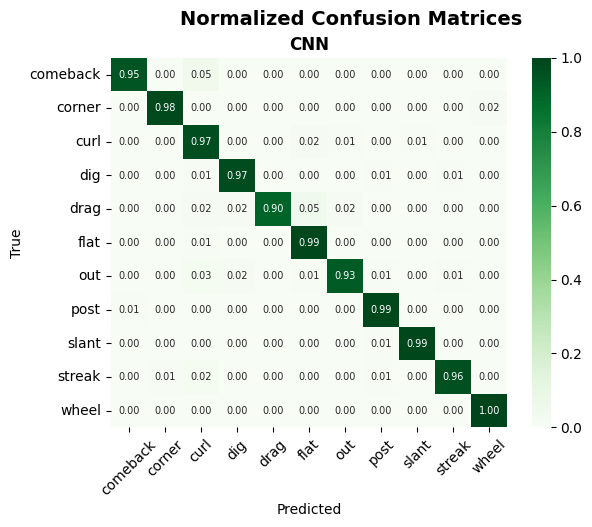

Transformer Test Results
Test Accuracy: 97.09%

              precision    recall  f1-score   support

    comeback       0.97      0.92      0.95        38
      corner       0.94      0.98      0.96        60
        curl       0.96      0.97      0.96       127
         dig       1.00      0.96      0.98       118
        drag       0.97      0.95      0.96        61
        flat       0.96      0.97      0.97       108
         out       0.96      0.96      0.96       113
        post       0.97      0.97      0.97        96
       slant       0.99      0.99      0.99        91
      streak       0.98      0.98      0.98       128
       wheel       0.98      1.00      0.99        57

    accuracy                           0.97       997
   macro avg       0.97      0.97      0.97       997
weighted avg       0.97      0.97      0.97       997



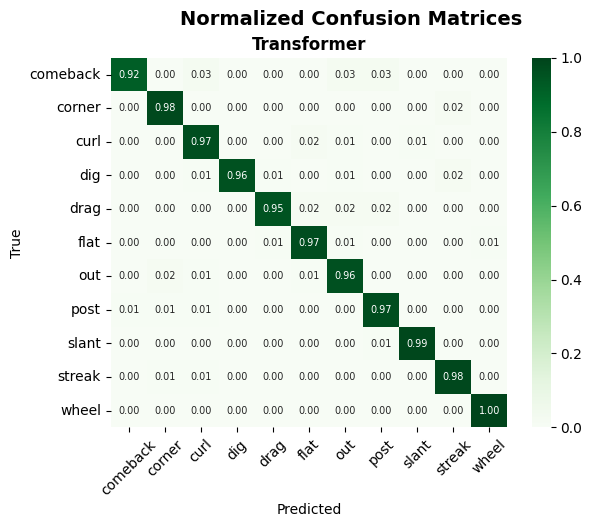

LSTM Test Results
Test Accuracy: 96.59%

              precision    recall  f1-score   support

    comeback       0.97      0.95      0.96        38
      corner       0.98      0.98      0.98        60
        curl       0.91      0.99      0.95       127
         dig       0.97      0.94      0.96       118
        drag       1.00      0.95      0.97        61
        flat       0.99      0.95      0.97       108
         out       0.95      0.93      0.94       113
        post       0.99      0.96      0.97        96
       slant       0.99      0.99      0.99        91
      streak       0.94      0.99      0.97       128
       wheel       1.00      0.98      0.99        57

    accuracy                           0.97       997
   macro avg       0.97      0.97      0.97       997
weighted avg       0.97      0.97      0.97       997



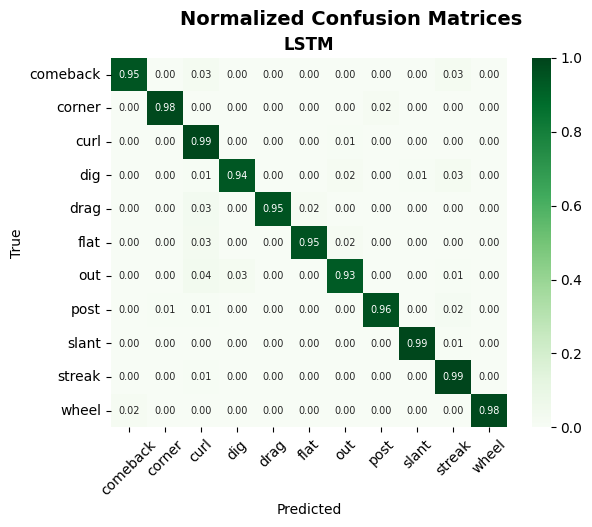

Image Test Results
Test Accuracy: 96.59%

              precision    recall  f1-score   support

    comeback       0.92      0.92      0.92        51
      corner       0.95      0.98      0.96        54
        curl       0.98      0.96      0.97       135
         dig       0.98      0.97      0.98       105
        drag       0.95      0.95      0.95        56
        flat       0.97      0.94      0.95       110
         out       0.96      0.98      0.97        90
        post       0.98      0.97      0.98       104
       slant       0.97      0.98      0.98       124
      streak       0.95      0.98      0.97       123
       wheel       0.99      0.97      0.98        73

    accuracy                           0.97      1025
   macro avg       0.96      0.96      0.96      1025
weighted avg       0.97      0.97      0.97      1025



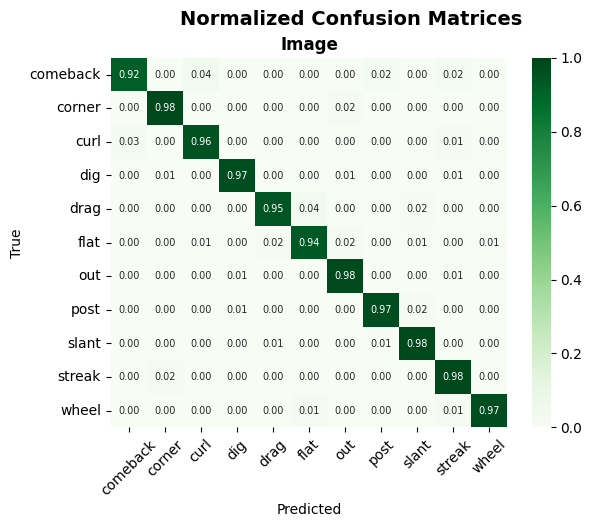

In [ ]:
print("1D CNN Test Results")
cnn_preds, cnn_labels, cnn_test_acc = evaluate_on_test(cnn_model, '/content/best_cnn.pth',
                                                       test_loader, class_names, device)
plot_confusion_matrices(cnn_preds, cnn_labels, class_names, name = 'CNN')

print("Transformer Test Results")
transformer_preds, transformer_labels, transformer_test_acc = evaluate_on_test(transformer_model, '/content/best_transformer.pth',
                                                                               test_loader, class_names, device)
plot_confusion_matrices(transformer_preds, transformer_labels, class_names, name = 'Transformer')

print("LSTM Test Results")
lstm_preds, lstm_labels, lstm_test_acc = evaluate_on_test(lstm_model, '/content/best_lstm.pth',
                                                          test_loader, class_names, device)
plot_confusion_matrices(lstm_preds, lstm_labels, class_names, name = 'LSTM')

print("Image Test Results")
img_preds, img_labels, img_test_acc = evaluate_on_test(image_model, '/content/best_image.pth',
                                                        test_loader_img, class_names, device)
plot_confusion_matrices(img_preds, img_labels, class_names, name = 'Image')

Same as above, just storing results together

In [ ]:
# running function for all models on test data to compare results
models_to_eval = {'CNN': (cnn_model, '/content/best_cnn.pth'),
                  'Transformer': (transformer_model, '/content/best_transformer.pth'),
                  'LSTM': (lstm_model, '/content/best_lstm.pth'),
                  'Image': (image_model, '/content/best_image.pth')}

results = {}
for name, (model, path) in models_to_eval.items():
    if name == 'Image':
        test_loader = test_loader_img
    else:
        test_loader = test_loader
    preds, labels, probs = get_all_predictions(model, path, test_loader, device)
    results[name] = {'preds': preds, 'labels': labels, 'probs': probs}

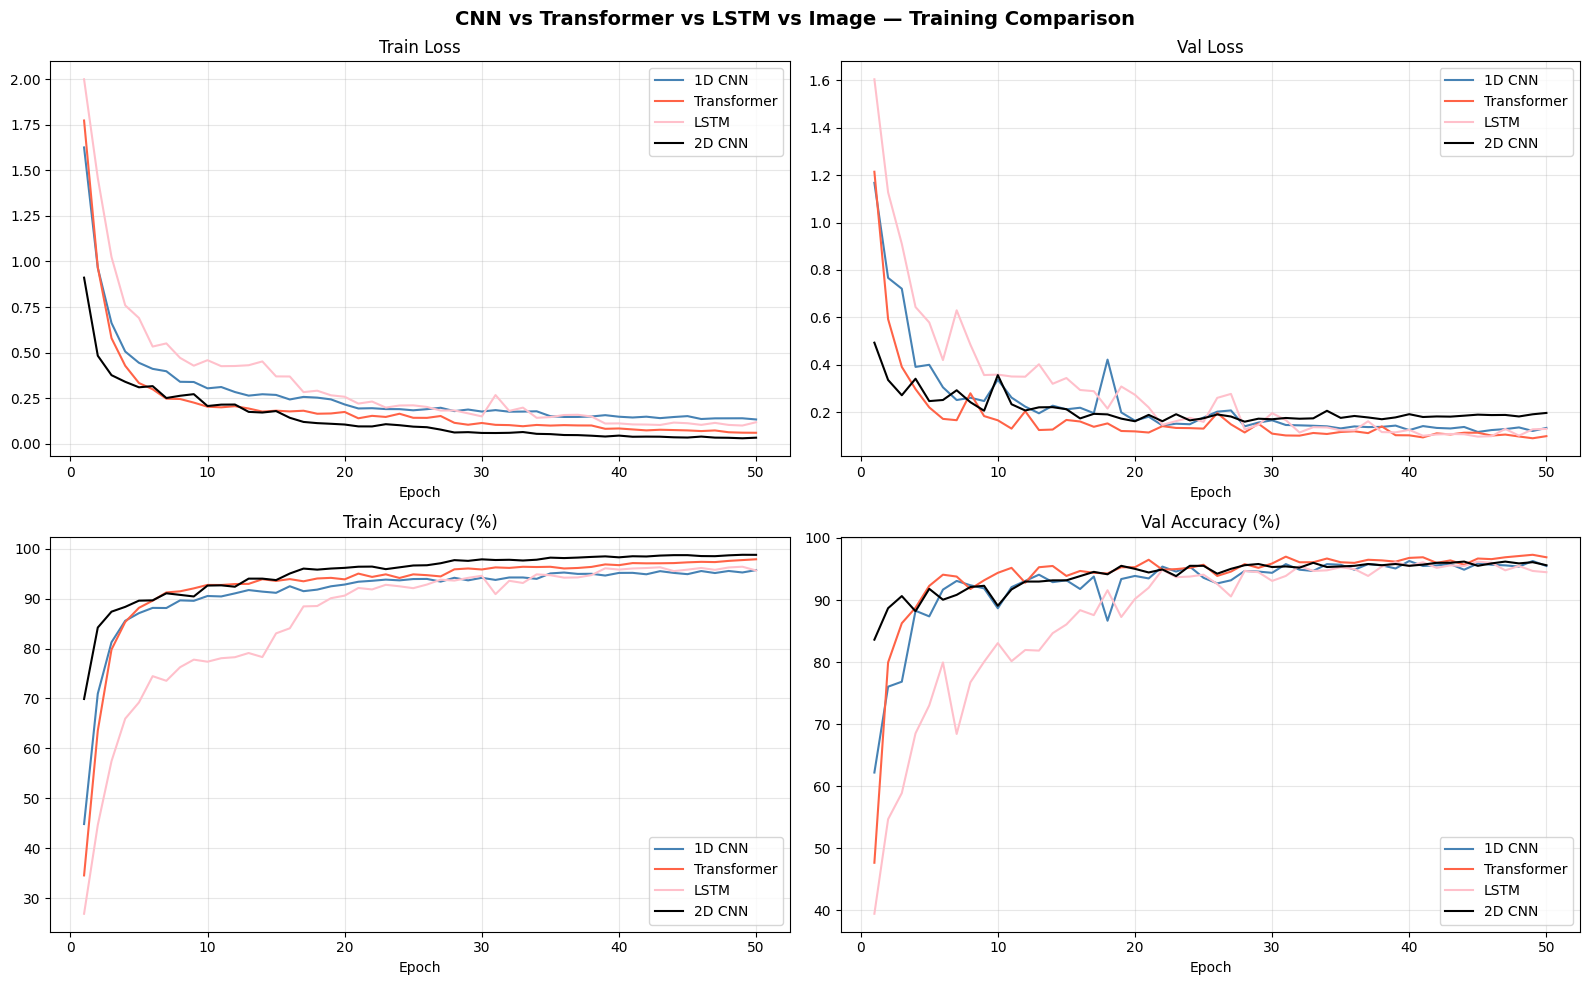

In [ ]:
# code to plot the training and validation curves to compare across models
fig, axes = plt.subplots(2, 2, figsize = (16, 10))
fig.suptitle('CNN vs Transformer vs LSTM vs Image — Training Comparison', fontsize = 14, fontweight = 'bold')

epochs = range(1, 51)
pairs = [(axes[0, 0], 'train_loss', 'Train Loss'),
        (axes[0, 1], 'val_loss', 'Val Loss'),
        (axes[1, 0], 'train_acc', 'Train Accuracy (%)'),
        (axes[1, 1], 'val_acc', 'Val Accuracy (%)')]

# for each model plotting results
for ax, key, title in pairs:
    ax.plot(epochs, cnn_history[key], label='1D CNN', color = 'steelblue')
    ax.plot(epochs, transformer_history[key], label = 'Transformer', color = 'tomato')
    ax.plot(epochs, lstm_history[key], label = 'LSTM', color = 'pink')
    ax.plot(epochs, image_history[key], label = '2D CNN', color = 'black')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

----

# Inference and Prediction on All-22 Videos

Class for getting predicted route labels for an entire video for skill position players/

In [ ]:
image_normalizer = transforms.Normalize(mean = IMAGENET_MEAN, std = IMAGENET_STD)

class RouteClassifier:
  # initializing
  def __init__(self, model, model_path, class_mapping_path, device = None, input_type = 'trajectory'):
    self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    self.input_type = input_type
    self.model = model
    self.model.load_state_dict(torch.load(model_path, map_location = self.device))
    self.model.to(self.device)
    self.model.eval()

    with open(class_mapping_path, 'r') as f:
        data = json.load(f)
    self.class_names = data['class_names']

  # two helper modules to convert inputted test data into appropriate tensor formatting
  # for sequential data
  def _coords_to_trajectory_tensor(self, x, y):
    return torch.FloatTensor(np.stack([x, y])).unsqueeze(0).to(self.device)

  # for image data
  def _coords_to_image_tensor(self, x, y, image_size = 64):
    from PIL import Image, ImageDraw

    padding = 5
    drawable = image_size - 2 * padding

    img = Image.new('RGB', (image_size, image_size), (255, 255, 255))
    draw = ImageDraw.Draw(img)

    px = (x * drawable + padding).astype(int)
    py = (y * drawable + padding).astype(int)
    px = np.clip(px, 0, image_size - 1)
    py = np.clip(py, 0, image_size - 1)

    points = [(int(xi), int(yi)) for xi, yi in zip(px, py)]
    if len(points) >= 2:
        draw.line(points, fill=(30, 100, 255), width=2)

    dot_r = 3
    draw.ellipse([points[0][0]-dot_r, points[0][1]-dot_r,
                  points[0][0]+dot_r, points[0][1]+dot_r], fill=(0, 210, 0))
    draw.ellipse([points[-1][0]-dot_r, points[-1][1]-dot_r,
                  points[-1][0]+dot_r, points[-1][1]+dot_r], fill=(220, 30, 30))

    # (H,W,3) → (3,H,W) float tensor in [0,1], then ImageNet normalize
    arr = torch.FloatTensor(np.array(img).transpose(2, 0, 1)) / 255.0
    return image_normalizer(arr).unsqueeze(0).to(self.device)

  # for a givent trajectory make classification preditions
  def classify(self, x_coords, y_coords, top_n = 3):
    x = np.array(x_coords, dtype = np.float32)
    y = np.array(y_coords, dtype = np.float32)

    # Pad or truncate to 64 points
    if len(x) < 64:
        x = np.pad(x, (0, 64 - len(x)), mode='edge')
        y = np.pad(y, (0, 64 - len(y)), mode='edge')
    else:
        x, y = x[:64], y[:64]

    # Build the right tensor format depending on model type
    if self.input_type == 'image':
        tensor = self._coords_to_image_tensor(x, y)
    else:
        tensor = self._coords_to_trajectory_tensor(x, y)

    with torch.no_grad():
        probs = torch.softmax(self.model(tensor), dim=1)[0]
        top_probs, top_indices = torch.topk(probs, k=min(top_n, len(self.class_names)))

    top_n_results = [{'route': self.class_names[idx.item()], 'confidence': prob.item()}
                      for prob, idx in zip(top_probs, top_indices)]

    return {'predicted_class': top_n_results[0]['route'],
            'confidence': top_n_results[0]['confidence'],
            f'top{top_n}': top_n_results,
            'probabilities': {name: probs[i].item() for i, name in enumerate(self.class_names)}}

  # take classify logic and apply to all skill position players in a test video
  def classify_file(self, json_path, top_n = 3):
      with open(json_path, 'r') as f:
          data = json.load(f)

      results = []
      for traj in data.get('trajectories', []):
          result = self.classify(traj['x_coords'], traj['y_coords'], top_n=top_n)
          result['track_id'] = traj.get('track_id', 'unknown')
          result['source_file'] = Path(json_path).name
          results.append(result)

      return results

  # output results
  def classify_and_print(self, json_path, top_n = 3):
      predictions = self.classify_file(json_path, top_n=top_n)
      print(f"\nResults for: {Path(json_path).name}")
      print("-" * 50)
      for pred in predictions:
          top_str = ' | '.join(
              f"{t['route']} {t['confidence']:.1%}" for t in pred[f'top{top_n}']
          )
          print(f"Track {pred['track_id']}: {top_str}")
      return predictions

Running class pipeline on a test video to see predicted routes for all skill players

In [ ]:
CLASS_MAPPING = '/content/drive/MyDrive/NFL_Route_Tracker/training_data/class_mapping.json'

classifiers = {'CNN': RouteClassifier(RouteCNN(num_classes = num_classes),
                                      '/content/best_cnn.pth', CLASS_MAPPING),
              'LSTM': RouteClassifier(RouteLSTM(num_classes=num_classes),
                                      '/content/best_lstm.pth', CLASS_MAPPING),
              'Transformer': RouteClassifier(RouteTransformer(num_classes = num_classes),
                                            '/content/best_transformer.pth', CLASS_MAPPING),
              'Image': RouteClassifier(RouteImageCNN(num_classes = num_classes),
                                      '/content/best_image.pth', CLASS_MAPPING, input_type='image')}

# TEST VIDEO
json_file = '/content/drive/MyDrive/NFL_Route_Tracker/training_data/vid109_normalized.json'

for model_name, classifier in classifiers.items():
    print(f"\n{'='*50}")
    print(f"Model: {model_name}")
    classifier.classify_and_print(json_file, top_n=3)


Model: CNN

Results for: vid109_normalized.json
--------------------------------------------------
Track 1: curl 57.5% | comeback 16.1% | dig 13.8%
Track 2: curl 56.2% | post 10.3% | streak 7.7%
Track 3: dig 26.9% | curl 26.3% | streak 13.9%
Track 4: dig 38.0% | curl 31.9% | comeback 6.8%

Model: LSTM

Results for: vid109_normalized.json
--------------------------------------------------
Track 1: post 21.5% | curl 21.2% | streak 17.6%
Track 2: curl 21.6% | post 19.7% | streak 17.5%
Track 3: post 22.9% | streak 22.0% | dig 13.5%
Track 4: curl 22.8% | comeback 19.6% | dig 15.4%

Model: Transformer

Results for: vid109_normalized.json
--------------------------------------------------
Track 1: curl 43.1% | dig 36.5% | streak 5.7%
Track 2: curl 81.7% | comeback 6.8% | post 5.4%
Track 3: streak 38.7% | dig 23.4% | post 15.1%
Track 4: dig 38.7% | streak 21.7% | curl 17.7%

Model: Image

Results for: vid109_normalized.json
--------------------------------------------------
Track 1: comeback 

Function for running classification of all models for all all-22 videos processed to view distribution of routes ran

In [ ]:
def compute_route_distribution(classifier, video_folder, top_n = 1):
  route_counts = defaultdict(int)
  total_trajectories = 0
  file_distributions = {}

  json_files = list(Path(video_folder).glob('*.json'))

  # go through each video file and run predictions on each route
  for json_path in json_files:
    predictions = classifier.classify_file(json_path, top_n = top_n)
    file_counts = defaultdict(int)

    # store route predictions
    for pred in predictions:
      total_trajectories += 1
      if top_n == 1:
        route = pred['predicted_class']
        route_counts[route] += 1
        file_counts[route] += 1
      else:
        for entry in pred[f'top{top_n}']:
          route_counts[entry['route']] += entry['confidence']
          file_counts[entry['route']] += entry['confidence']

    # convert THIS FILE to fractions
    total_file = sum(file_counts.values())
    if total_file > 0:
        file_fractions = {r: c / total_file for r, c in file_counts.items()}
    else:
        file_fractions = {}

    file_distributions[json_path.name] = file_fractions

  total = sum(route_counts.values())
  route_fractions = {r: c / total for r, c in sorted(route_counts.items())}

  return {'counts': dict(route_counts),
          'fractions': route_fractions,
          'total_trajectories': total_trajectories,
          'per_file': file_distributions}

Visualization using distribution data to plot as boxplots

In [ ]:
def plot_model_comparison_bars(all_model_dists, class_names):
    model_names = list(all_model_dists.keys())
    n_models = len(model_names)
    n_classes = len(class_names)

    fig, ax = plt.subplots(figsize=(14, 6))

    width = 0.18
    x = np.arange(n_classes)
    colors = ['steelblue', 'tomato', 'seagreen', 'mediumpurple']

    for i, model_name in enumerate(model_names):
        dist = all_model_dists[model_name]

        means = []
        for route in class_names:
            vals = [file_dist.get(route, 0) for file_dist in dist['per_file'].values()]
            means.append(np.mean(vals) if vals else 0)

        positions = x + (i - (n_models - 1) / 2) * width
        ax.bar(positions, means, width=width, color=colors[i % len(colors)],
               alpha=0.85, label=model_name)

    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=35, ha='right')
    ax.set_ylabel('Mean Fraction of Routes')
    ax.set_title('Mean Route Distribution Across Models')
    ax.set_ylim(0, 0.5)
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()

    plt.tight_layout()
    plt.show()


Processing — CNN
Total trajectories processed: 1236
  comeback     2.9%  (n=36)
  corner       2.9%  (n=36)
  curl         26.2%  (n=324)
  dig          7.8%  (n=96)
  drag         3.2%  (n=40)
  flat         24.4%  (n=302)
  out          5.0%  (n=62)
  post         12.5%  (n=154)
  slant        2.4%  (n=30)
  streak       9.7%  (n=120)
  wheel        2.9%  (n=36)

Processing — LSTM
Total trajectories processed: 1236
  comeback     2.4%  (n=30)
  corner       0.2%  (n=2)
  curl         24.6%  (n=304)
  dig          1.1%  (n=14)
  drag         7.4%  (n=92)
  flat         21.4%  (n=264)
  out          10.5%  (n=130)
  post         12.3%  (n=152)
  slant        1.0%  (n=12)
  streak       16.8%  (n=208)
  wheel        2.3%  (n=28)

Processing — Transformer
Total trajectories processed: 1236
  comeback     3.2%  (n=40)
  corner       1.9%  (n=24)
  curl         20.1%  (n=248)
  dig          5.0%  (n=62)
  drag         3.4%  (n=42)
  flat         23.1%  (n=286)
  out          9.9%  (n=122)

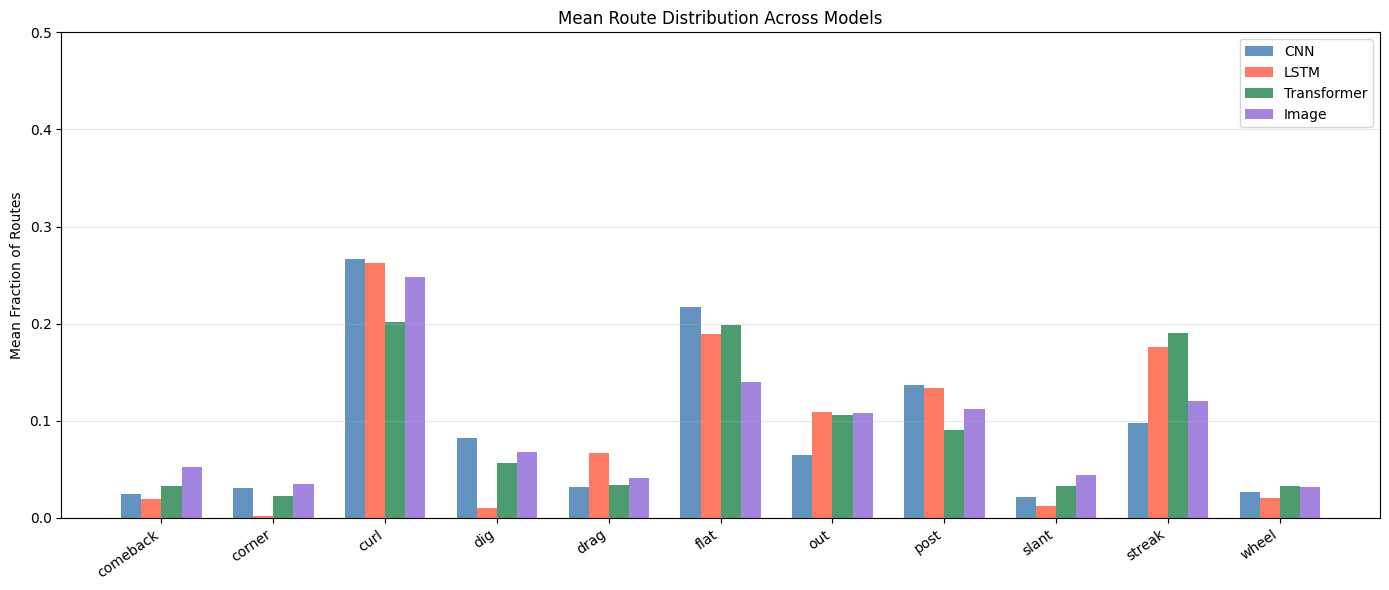

In [ ]:
VIDEO_FOLDER = '/content/drive/MyDrive/NFL_Route_Tracker/normalized_trajectories/'

all_model_dists = {}

# running above code to analyze all all-22 videos for each model and compare results
for model_name, classifier in classifiers.items():
    print(f"\n{'='*50}\nProcessing — {model_name}")
    dist = compute_route_distribution(classifier, VIDEO_FOLDER, top_n = 1)
    all_model_dists[model_name] = dist

    print(f"Total trajectories processed: {dist['total_trajectories']}")
    for route, frac in dist['fractions'].items():
        print(f"  {route:<12} {frac:.1%}  (n={dist['counts'][route]})")

# single plot here
plot_model_comparison_bars(all_model_dists, class_names)

# Extra Exploratory Work for Non-Trained, Manually Labeled Real Data

In [ ]:
# compare model results by specific classes
def compute_per_class_metrics(results, class_names):
  metrics = {}

  for model_name, res in results.items():
    report = classification_report(res['labels'], res['preds'],
                                    target_names = class_names,
                                    output_dict = True,
                                    zero_division = 0)
    metrics[model_name] = {cls: {'precision': report[cls]['precision'],
                                 'recall': report[cls]['recall'],
                                 'f1': report[cls]['f1-score'],
                                 'support': report[cls]['support']}
                           for cls in class_names}

  return metrics

# vizualization mechanic for per-class results
def print_scorecard_table(metrics, class_names, metric = 'f1', route_counts = None):
  model_names = list(metrics.keys())

  rows = []
  for cls in class_names:
    row  = {'Route': cls}
    best_val = -1

    for model_name in model_names:
      val = metrics[model_name][cls][metric]
      row[model_name] = f'{val:.3f}'
      if val > best_val:
        best_val = val

    # Append count if provided
    if route_counts is not None:
      n = route_counts.get(cls, 0)
      row['n (real)'] = n

    rows.append(row)

  # re organizing column order
  cols = ['Route']
  if route_counts is not None:
      cols += ['n (real)']
  cols += model_names

  df = pd.DataFrame(rows).set_index('Route')[cols[1:]]

  print(f"\nHead-to-Head Comparison ({metric.upper()})")
  print("=" * 65)
  print(df.to_string())

# ── Run everything ──────────────────────────────────────────
metrics = compute_per_class_metrics(results, class_names)
print_scorecard_table(metrics, class_names, metric = 'f1')



Head-to-Head Comparison (F1)
            CNN Transformer   LSTM  Image
Route                                    
comeback  0.960       0.946  0.960  0.922
corner    0.983       0.959  0.983  0.964
curl      0.943       0.965  0.947  0.966
dig       0.975       0.978  0.957  0.976
drag      0.948       0.959  0.975  0.946
flat      0.968       0.968  0.972  0.954
out       0.955       0.960  0.942  0.967
post      0.974       0.969  0.974  0.976
slant     0.989       0.989  0.989  0.976
streak    0.972       0.981  0.966  0.968
wheel     0.991       0.991  0.991  0.979


In [ ]:
# function to evaluate only on the manually labeled holdout set
def evaluate_on_real_labels(classifiers, holdout_labels_path, top_n=1):
  with open(holdout_labels_path, 'r') as f:
    data = json.load(f)

  entries = data['labels']
  print(f"Evaluating on {len(entries)} held-out labels")

  route_counts = Counter(e['route_type'] for e in entries)
  print("Holdout Label Distribution:")
  print("-" * 40)
  for route in sorted(route_counts):
    print(f"{route:<12} n = {route_counts[route]:>3}")
  print(f"{'TOTAL':<12} n = {len(entries):>3}")
  print("-" * 40 + "\n")

  real_results = {}

  for model_name, classifier in classifiers.items():
    all_preds, all_labels, all_probs = [], [], []

    for entry in entries:
      result = classifier.classify(entry['x_coords'], entry['y_coords'], top_n=top_n)
      pred_idx = classifier.class_names.index(result['predicted_class'])
      true_idx = classifier.class_names.index(entry['route_type'])
      probs_vec = [result['probabilities'][c] for c in classifier.class_names]

      all_preds.append(pred_idx)
      all_labels.append(true_idx)
      all_probs.append(probs_vec)

    y_pred = np.array(all_preds)
    y_true = np.array(all_labels)

    real_results[model_name] = {'preds': y_pred,
                                'labels': y_true,
                                'probs': np.array(all_probs),}

    acc = accuracy_score(y_true, y_pred)
    f1_micro = f1_score(y_true, y_pred, average='micro', zero_division=0)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"{model_name}: acc={acc:.1%}, micro F1={f1_micro:.1%}, "
          f"macro F1={f1_macro:.1%}, weighted F1={f1_weighted:.1%} "
          f"({len(all_preds)} samples)")

  return real_results, route_counts


real_results, route_counts = evaluate_on_real_labels(classifiers, # CHANGE TO HOLDOUT LABELS JSON AFTER DOING IT CORRECTLY
                                                     holdout_labels_path = '/content/drive/MyDrive/NFL_Route_Tracker/training_data/holdout_labels.json')

real_metrics = compute_per_class_metrics(real_results, class_names)
print_scorecard_table(real_metrics, class_names, metric = 'f1', route_counts = route_counts)

Evaluating on 101 held-out labels
Holdout Label Distribution:
----------------------------------------
comeback     n =   7
corner       n =   3
curl         n =  15
dig          n =   9
drag         n =   5
flat         n =  13
out          n =  11
post         n =  12
slant        n =   6
streak       n =  14
wheel        n =   6
TOTAL        n = 101
----------------------------------------

CNN: acc=49.5%, micro F1=49.5%, macro F1=44.5%, weighted F1=47.8% (101 samples)
LSTM: acc=37.6%, micro F1=37.6%, macro F1=27.7%, weighted F1=34.2% (101 samples)
Transformer: acc=54.5%, micro F1=54.5%, macro F1=50.6%, weighted F1=53.9% (101 samples)
Image: acc=54.5%, micro F1=54.5%, macro F1=50.1%, weighted F1=54.1% (101 samples)

Head-to-Head Comparison (F1)
          n (real)    CNN   LSTM Transformer  Image
Route                                              
comeback         7  0.000  0.000       0.364  0.182
corner           3  0.000  0.000       0.000  0.222
curl            15  0.389  0.364  